In [54]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")


PyTorch version: 2.2.2
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [56]:
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

In [57]:
import sys
from pathlib import Path
from pathlib import Path

_cwd = Path().resolve()
_candidates = (_cwd, _cwd.parent)
for _root in _candidates:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator' package; adjust sys.path.")

del _cwd, _candidates, _root


# Code

In [58]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['label'] += offset
        out_graphs.append(graph.copy())
    return out_graphs, targets

In [59]:
from coco_grape.visualizer.display import draw_graphs
def plot_sample(sampled_graphs, sampled_targets, haystack=None, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    gs = pos_graphs + neg_graphs
    if haystack is not None:
        ts = list(compute_is_valid(pos_graphs, haystack)) + list(compute_is_valid(neg_graphs, haystack))
        draw_graphs(gs, ts, n_graphs_per_line=n_graphs_per_line)
    else:
        draw_graphs(gs, n_graphs_per_line=n_graphs_per_line)

In [60]:
def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    return pos_graphs, neg_graphs

In [61]:
import math
import hashlib
import matplotlib.pyplot as plt
import networkx as nx
from coco_grape.visualizer.mol_display import draw_molecules
    
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=4, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    """
    Plot a list of NetworkX graphs in a grid.
    
    Each node is drawn with a color determined by its 'label' attribute.
    The color is chosen persistently (so nodes with the same label always get the same color)
    and then lightened by the given factor.
    
    Parameters:
        graphs (list): List of networkx.Graph objects.
        cmap: Matplotlib colormap or a string name for a colormap. Defaults to 'Set2'.
        light (float): A value in [0, 1] used to lighten colors 
                       (0 leaves the color unchanged, 1 turns it white). Defaults to 0.3.
        size (int, optional): Size (in inches) for each individual square plot (default: 4).
        n_cols (int, optional): Number of columns in the grid. If None, defaults to the number of graphs.
        show_label (bool, optional): If True, displays the node's label on the plot.
    """
    if mode == 'molecule':
        draw_molecules(graphs)
        return
        
    # If cmap is given as a string, get the corresponding matplotlib colormap
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
        
    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)
    
    # Create subplots with no border on the plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    
    # Ensure axes is a flat list (handle case with one or multiple rows/cols)
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes.flatten())
    else:
        axes = axes.flatten()
    
    def get_color_for_label(label):
        """
        Given a label (string), returns a persistent color based on a hash.
        The base color is obtained from the cmap and then lightened.
        """
        label_str = str(label)
        # Use MD5 for a deterministic hash (consistent across invocations)
        hash_val = hashlib.md5(label_str.encode('utf-8')).hexdigest()
        numeric_hash = int(hash_val, 16)+color_offset
        # Normalize to [0, 1] using mod 1000 for a quick spread
        normalized = (numeric_hash % 1000) / 999.0
        base_color = cmap(normalized)  # returns an RGBA tuple
        
        # Lighten the color: interpolate between base_color and white (1,1,1)
        lightened = tuple((1 - light) * base_color[i] + light for i in range(3))
        # Preserve alpha if available
        if len(base_color) == 4:
            lightened += (base_color[3],)
        return lightened

    # Loop over each graph and plot it on its corresponding axis
    for i, G in enumerate(graphs):
        ax = axes[i]
        ax.axis('off')  # Remove borders/ticks
        
        # Compute layout using the Kamada–Kawai algorithm
        pos = nx.kamada_kawai_layout(G)
        
        # Get colors for nodes using the node's 'label' attribute
        node_colors = []
        labels = {}
        for n in G.nodes():
            label = G.nodes[n].get('label', '')
            node_colors.append(get_color_for_label(label))
            labels[n] = str(label)
            
        # Draw edges and nodes with a black border for each node
        nx.draw_networkx_edges(G, pos, width=2, ax=ax)
        nx.draw_networkx_nodes(
            G, pos, ax=ax, node_color=node_colors, edgecolors='black', linewidths=2,
        )
        
        # Optionally, draw labels if show_label is True
        if show_label:
            nx.draw_networkx_labels(G, pos, labels=labels, ax=ax)
    
    # Hide any unused axes if the grid is larger than the number of graphs
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


In [62]:
def show_samples(n_samples, graphs, targets, graph_generator):
    def _show_group(title, seed_graphs):
        print(f"{title} Graphs:")
        plot_networkx_graphs(seed_graphs[:n_samples], n_cols=n_samples)

        unfiltered_graphs = graph_generator.sample_conditioned_on_random(
            seed_graphs,
            n_samples,
            apply_feasibility_filtering=False,
        )
        print(f"Sampled {title} Graphs Without Feasibility Filtering ({len(unfiltered_graphs)}/{n_samples}):")
        plot_networkx_graphs(unfiltered_graphs, n_cols=max(1, len(unfiltered_graphs)))

        filtered_graphs = graph_generator.sample_conditioned_on_random(
            seed_graphs,
            n_samples,
            apply_feasibility_filtering=True,
        )
        print(f"Sampled {title} Graphs With Feasibility Filtering ({len(filtered_graphs)}/{n_samples}):")
        plot_networkx_graphs(filtered_graphs, n_cols=max(1, len(filtered_graphs)))

    neg_graphs = [graph for graph, target in zip(graphs, targets) if target == 0]
    pos_graphs = [graph for graph, target in zip(graphs, targets) if target != 0]

    _show_group("Positive", pos_graphs)
    _show_group("Negative", neg_graphs)

In [63]:
def graph_label_histogram(graph, label_classes):
    hist = np.zeros(len(label_classes), dtype=float)
    class_to_idx = {label: idx for idx, label in enumerate(label_classes)}
    for _, data in graph.nodes(data=True):
        label = data.get("label")
        if label in class_to_idx:
            hist[class_to_idx[label]] += 1.0
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def summarize_label_histogram_alignment(graph_generator, graphs, n_compare=16):
    eqm_generator = graph_generator.conditional_node_generator_model
    label_classes = [int(label) if isinstance(label, np.integer) else label for label in eqm_generator.node_label_classes_]
    print("Label vocabulary:", label_classes)

    input_graphs = graphs[:n_compare]
    graph_conditioning = graph_generator.graph_encode(input_graphs)
    conditioning_histograms = np.vstack([
        graph_label_histogram(graph, label_classes) for graph in input_graphs
    ])
    print(
        "Conditioning histogram from first real graph:",
        {label: float(value) for label, value in zip(label_classes, conditioning_histograms[0].round(3))},
    )

    if getattr(graph_generator, "feasibility_estimator", None) is not None:
        decoded_slots = graph_generator._decode_with_feasibility_slots(graph_conditioning)
        matched_pairs = [
            (conditioning_histograms[idx], graph)
            for idx, graph in enumerate(decoded_slots)
            if graph is not None
        ]
        if not matched_pairs:
            raise RuntimeError("No feasible generated graphs were available for histogram comparison.")
        if len(matched_pairs) < len(input_graphs):
            print(f"Histogram comparison uses {len(matched_pairs)}/{len(input_graphs)} feasible generated graphs.")
        conditioning_histograms = np.vstack([conditioning_hist for conditioning_hist, _ in matched_pairs])
        generated_graphs = [graph for _, graph in matched_pairs]
    else:
        generated_graphs = graph_generator.decode(graph_conditioning)
    generated_histograms = np.vstack([
        graph_label_histogram(graph, label_classes) for graph in generated_graphs
    ])
    histogram_diff = generated_histograms - conditioning_histograms
    abs_diff = np.abs(histogram_diff)

    summary = {
        "label_classes": label_classes,
        "mean_conditioning": conditioning_histograms.mean(axis=0),
        "mean_generated": generated_histograms.mean(axis=0),
        "mean_diff": histogram_diff.mean(axis=0),
        "mean_abs_diff": abs_diff.mean(axis=0),
        "average_l1_error": abs_diff.sum(axis=1).mean(),
    }
    summary["mistake_order"] = np.argsort(-summary["mean_abs_diff"])

    print("Mean conditioning histogram:", {label: float(value) for label, value in zip(label_classes, summary["mean_conditioning"].round(3))})
    print("Mean generated histogram:", {label: float(value) for label, value in zip(label_classes, summary["mean_generated"].round(3))})
    print("Average L1 histogram error per graph:", round(float(summary["average_l1_error"]), 4))
    print("Most mistaken labels:")
    for idx in summary["mistake_order"][: min(10, len(label_classes))]:
        print(
            f"  {label_classes[idx]}: mean_abs_diff={summary['mean_abs_diff'][idx]:.4f}, "
            f"generated-conditioning={summary['mean_diff'][idx]:+.4f}"
        )
    return summary

def plot_label_histogram_alignment(summary):
    label_classes = summary["label_classes"]
    mean_conditioning = summary["mean_conditioning"]
    mean_generated = summary["mean_generated"]
    mean_abs_diff = summary["mean_abs_diff"]
    mean_diff = summary["mean_diff"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    x = np.arange(len(label_classes))
    width = 0.38

    axes[0].bar(x - width / 2, mean_conditioning, width, label="conditioning")
    axes[0].bar(x + width / 2, mean_generated, width, label="generated")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(label_classes, rotation=45, ha="right")
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Average label histogram")
    axes[0].legend()

    axes[1].bar(x, mean_abs_diff, color="tomato")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(label_classes, rotation=45, ha="right")
    axes[1].set_ylim(0, max(0.05, mean_abs_diff.max() * 1.2))
    axes[1].set_title("Average absolute histogram difference")

    axes[2].bar(x, mean_diff, color=["seagreen" if v >= 0 else "firebrick" for v in mean_diff])
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(label_classes, rotation=45, ha="right")
    axes[2].set_title("Signed histogram bias")

    plt.tight_layout()
    plt.show()


---

# Data

In [64]:
DATASET_TYPE = 'ARTIFICIAL'  # Uncomment to use the synthetic dataset instead.

In [65]:
DATASET_TYPE = 'MOLECULAR'

In [66]:
def build_dataset(dataset_size=50, size = 5):
    if DATASET_TYPE == 'ARTIFICIAL':
        from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor
        graph_types = ['path', 'tree', 'cycle', 'degree', 'regular', 'dense']
        alphabet_size = 3
        
        graphs, targets = ArtificialGraphDatasetConstructor(
            graph_generator_target_type_pos='cycle', 
            graph_generator_context_type_pos='cycle', 
            graph_generator_target_type_neg='tree',
            graph_generator_context_type_neg='tree', 
            target_size_pos=size, 
            context_size_pos=size, 
            n_link_edges_pos=1,
            alphabet_size_pos=alphabet_size,
            target_size_neg=size, 
            context_size_neg=size, 
            n_link_edges_neg=1,
            alphabet_size_neg=alphabet_size).sample(dataset_size//2)

        graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)

        from coco_grape.utils.canonical_order import canonicalise
        #graphs = [canonicalise(graph) for graph in graphs]

        #graph_array = np.empty(len(graphs), dtype=object)
        #for i, graph in enumerate(graphs): graph_array[i] = graph
        #graphs = graph_array
        #haystack = np.unique(make_graph_signature_mtx(graphs),axis=0)
        #print('dataset has %d different templates'%len(haystack))
        print('#graphs:%d'%(len(graphs)))
        
        n_graphs_per_line = 8
        pos_graphs, neg_graphs = select_pos_neg(graphs, targets, n_lines=1, n_graphs_per_line=n_graphs_per_line)
        #plot_sample(graphs, targets, haystack)
        plot_networkx_graphs(pos_graphs, n_cols=n_graphs_per_line)
        plot_networkx_graphs(neg_graphs, n_cols=n_graphs_per_line)
        

    elif DATASET_TYPE == 'MOLECULAR':
        from coco_grape.visualizer.mol_display import draw_molecules
        
        from coco_grape.data_loader.mol.mol_loader import PubChemLoader
        assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213','651610', '630']
        from coco_grape.data_loader.loader import SupervisedDataSetLoader
        assay_id=assay_ids[-4]
        assay_id = '651610'
        def pubchem_loader(): return PubChemLoader().load(assay_id)
        original_graphs, original_targets = SupervisedDataSetLoader(pubchem_loader, size=dataset_size, use_equalized=False).load()
        original_graphs = np.array(original_graphs, dtype=object)
        original_targets = np.array(original_targets)
        print('#graphs:%d   class split:%s'%(len(original_graphs), np.bincount(original_targets)))

        max_node_size = size
        print('...filter by size <= %d'%max_node_size)
        idxs = [idx for idx, graph in enumerate(original_graphs) if nx.number_of_nodes(graph)<=max_node_size]
        print('#graphs:%d '%(len(idxs)))
        graphs = original_graphs[idxs].tolist()
        targets = original_targets[idxs]

        from coco_grape.visualizer.mol_display import draw_molecules
        draw_molecules(graphs[:7*2])
    return graphs, targets

---

# Experiment

In [70]:
import sys
from pathlib import Path

for _root in [Path.cwd(), *Path.cwd().parents[:2]]:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator' package from current working directory.")

del _root, _root_str

from sklearn.model_selection import train_test_split

from NSPPK.nsppk import NSPPK, NodeNSPPK
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)
from eqm_decompositional_graph_generator.eqm_conditional_node_generator import EqMDecompositionalNodeGenerator
from eqm_decompositional_graph_generator.graph_generator import (
    EqMDecompositionalGraphDecoder,
    EqMDecompositionalGraphGenerator,
)
from interpolate import interpolate, sample_positive_endpoint_pair

REPO_ROOT = next(
    candidate.resolve()
    for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / 'eqm_decompositional_graph_generator').exists()
)
ARTIFACT_ROOT = REPO_ROOT / '.artifacts'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints' / 'eqm'

def prepare_experiment(dataset_size=200, test_size=10, random_state=42, size=25):
    graphs, targets = build_dataset(dataset_size=dataset_size, size=size)
    train_graphs, test_graphs, train_targets, test_targets = train_test_split(
        graphs,
        targets,
        test_size=test_size,
        random_state=random_state,
    )
    print(f"train_graphs:{len(train_graphs)}   test_graphs:{len(test_graphs)}")
    return graphs, targets, train_graphs, test_graphs, train_targets, test_targets

def fit_graph_generator(graph_generator, train_graphs):
    graph_generator.fit(train_graphs)
    return graph_generator

def run_label_histogram_analysis(graph_generator, graphs, n_compare=5):
    summary = summarize_label_histogram_alignment(
        graph_generator,
        graphs,
        n_compare=n_compare,
    )
    plot_label_histogram_alignment(summary)
    return summary

def _normalized_counter(values):
    series = pd.Series(list(values), dtype=object)
    if len(series) == 0:
        return pd.Series(dtype=float)
    counts = series.value_counts(dropna=False).sort_index(key=lambda idx: idx.map(str))
    return counts / counts.sum()

def _collect_graph_statistics(graphs):
    node_counts = [graph.number_of_nodes() for graph in graphs]
    edge_counts = [graph.number_of_edges() for graph in graphs]
    node_labels = [attrs.get('label') for graph in graphs for _, attrs in graph.nodes(data=True)]
    edge_labels = [attrs.get('label') for graph in graphs for _, _, attrs in graph.edges(data=True)]
    return {
        'node_count': _normalized_counter(node_counts),
        'edge_count': _normalized_counter(edge_counts),
        'atom_label': _normalized_counter(node_labels),
        'bond_label': _normalized_counter(edge_labels),
    }

def _compare_distribution(real_dist, generated_dist, metric_name):
    support = real_dist.index.union(generated_dist.index)
    real_aligned = real_dist.reindex(support, fill_value=0.0)
    generated_aligned = generated_dist.reindex(support, fill_value=0.0)
    comparison = pd.DataFrame({'real': real_aligned, 'generated': generated_aligned})
    comparison['abs_diff'] = (comparison['generated'] - comparison['real']).abs()
    tv_distance = 0.5 * comparison['abs_diff'].sum()
    print(f"{metric_name}: TV distance = {tv_distance:.4f}")
    return comparison.sort_index(key=lambda idx: idx.map(str)), tv_distance

def compare_real_vs_generated(graph_generator, reference_graphs, apply_feasibility_filtering=True):
    reference_graphs = list(reference_graphs)
    reference_conditioning = graph_generator.graph_encode(reference_graphs)
    decoded_slots = graph_generator._decode_with_feasibility_slots(
        reference_conditioning,
        apply_feasibility_filtering=apply_feasibility_filtering,
    )
    paired_graphs = [
        (real_graph, generated_graph)
        for real_graph, generated_graph in zip(reference_graphs, decoded_slots)
        if generated_graph is not None
    ]
    if not paired_graphs:
        raise RuntimeError('No feasible generated graphs were returned for the comparison set.')
    real_eval_graphs = [real_graph for real_graph, _ in paired_graphs]
    generated_eval_graphs = [generated_graph for _, generated_graph in paired_graphs]
    print(f"Compared {len(generated_eval_graphs)}/{len(reference_graphs)} feasible generated graphs.")
    real_stats = _collect_graph_statistics(real_eval_graphs)
    generated_stats = _collect_graph_statistics(generated_eval_graphs)
    comparison_tables = {}
    summary_rows = []
    metrics = [
        ('node_count', 'Node count'),
        ('edge_count', 'Edge count'),
        ('atom_label', 'Atom label'),
        ('bond_label', 'Bond label'),
    ]
    for metric_name, title in metrics:
        comparison, tv_distance = _compare_distribution(real_stats[metric_name], generated_stats[metric_name], title)
        comparison_tables[metric_name] = comparison
        summary_rows.append({'metric': title, 'tv_distance': tv_distance})
    distribution_summary = pd.DataFrame(summary_rows).sort_values('tv_distance')
    display(distribution_summary)
    for metric_name, title in metrics:
        print(title)
        display(comparison_tables[metric_name])
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (metric_name, title) in zip(axes.flatten(), metrics):
        table = comparison_tables[metric_name]
        x = np.arange(len(table))
        width = 0.38
        ax.bar(x - width / 2, table['real'], width, label='real')
        ax.bar(x + width / 2, table['generated'], width, label='generated')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([str(idx) for idx in table.index], rotation=45, ha='right')
        ax.legend()
    plt.tight_layout()
    plt.show()
    return {
        'summary': distribution_summary,
        'comparison_tables': comparison_tables,
        'real_graphs': real_eval_graphs,
        'generated_graphs': generated_eval_graphs,
    }



---

In [68]:

def build_graph_generator(nbits=11, verbose=2):
    node_graph_vectorizer = NodeNSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )

    feasibility_size = WithinRangeFeasibilityEstimatorFromNumericalFunction(
        numerical_function=lambda graph: len(graph),
        quantile=None,
    )
    feasibility_unlabeled_structure = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        nbits=19,
        parallel=True,
        backend="dill",
    )
    feasibility_valence = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        nbits=19,
        parallel=True,
        backend="dill",
    )
    feasibility_cycle = FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        nbits=19,
        parallel=True,
        backend="dill",
    )
    feasibility_estimator = FeasibilityEstimator(
        [feasibility_size, feasibility_valence, feasibility_cycle, feasibility_unlabeled_structure]
    )

    conditional_node_generator_model = EqMDecompositionalNodeGenerator(
        latent_embedding_dimension=128,
        number_of_transformer_layers=4,
        transformer_attention_head_count=4,
        transformer_dropout=0.2,
        learning_rate=1e-4,
        maximum_epochs=250,
        batch_size=16,
        total_steps=100,
        lambda_degree_importance=5e3,
        lambda_node_exist_importance=0,
        lambda_node_label_importance=5e4,
        lambda_edge_label_importance=5e3,
        lambda_locality_importance=1e4,
        degree_temperature=1,
        eqm_sigma=0.2,
        sampling_step_size=0.05,
        langevin_noise_scale=0.0,
        verbose=verbose,
        verbose_epoch_interval=10,
        enable_early_stopping=True,
        early_stopping_monitor="val_total",
        early_stopping_mode="min",
        early_stopping_patience=20,
        early_stopping_min_delta=100.0,
        restore_best_checkpoint=True,
        artifact_root_dir=str(ARTIFACT_ROOT),
        checkpoint_root_dir=str(CHECKPOINT_ROOT),
    )
    graph_decoder = EqMDecompositionalGraphDecoder(
        verbose=verbose,
        enforce_connectivity=True,
        warm_start_mst=True,
    )
    return EqMDecompositionalGraphGenerator(
        graph_vectorizer=graph_vectorizer,
        node_graph_vectorizer=node_graph_vectorizer,
        conditional_node_generator_model=conditional_node_generator_model,
        graph_decoder=graph_decoder,
        feasibility_estimator=feasibility_estimator,
        locality_sample_fraction=0.5,
        locality_horizon=1,
        negative_sample_factor=1,
        locality_sampling_strategy="stratified_preserve",
        locality_target_positive_ratio=0.5,
        max_feasibility_attempts=20,
        feasibility_candidates_per_attempt=8,
        feasibility_failure_mode="return_partial",
        verbose=verbose,
    )


#graphs:2000   class split:[1719  281]
...filter by size <= 27
#graphs:390 


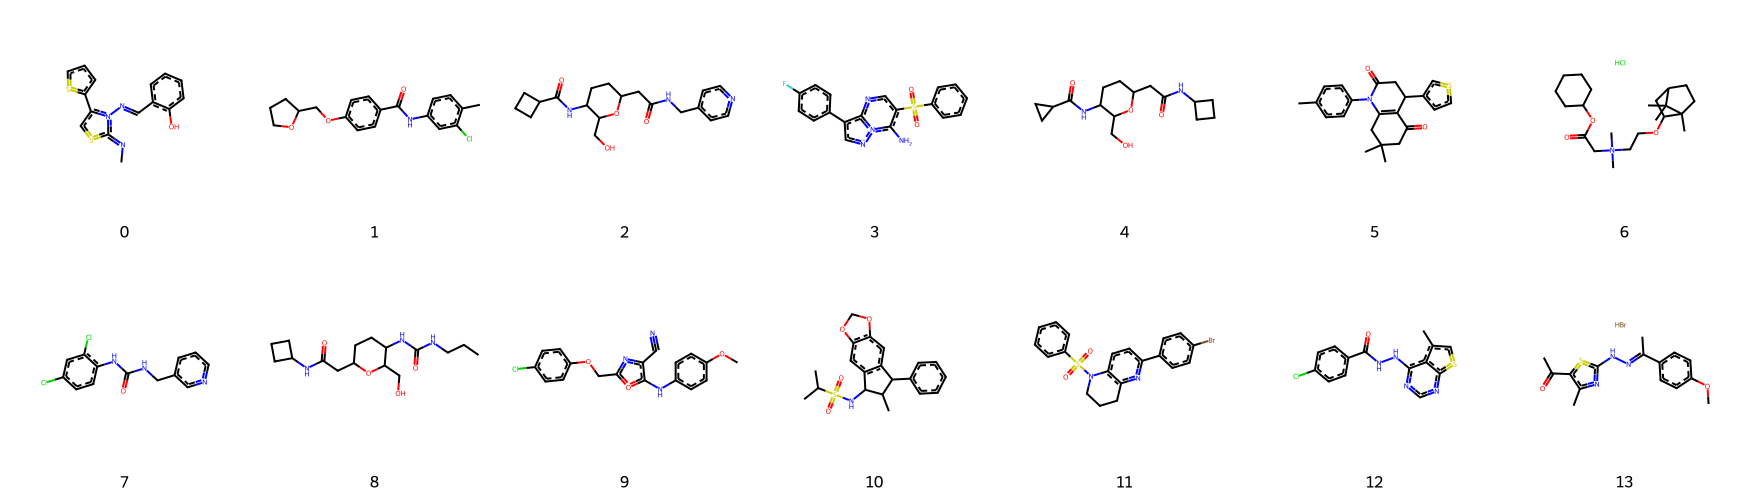

train_graphs:381   test_graphs:9


In [74]:
graphs, targets, train_graphs, test_graphs, train_targets, test_targets = prepare_experiment(
    dataset_size=2000,
    test_size=9,
    random_state=42,
    size=27
)
graph_generator = build_graph_generator(nbits=11, verbose=2)


Fitting model on 381 graphs
Fitting feasibility estimator on 381 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 8 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 58626 pairs (50.00%) from 117252 total pairs (pos=39084, neg=78168, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=19542, neg=39084, positive_ratio=0.333.
Training conditional model on 381 graphs with up to 27 nodes each.
Using direct-edge supervision with 58626 labelled pairs.
Direct edge supervision enabled: horizon-1 edge presence will be learned and used by the decoder.
Auxiliary locality supervision disab

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                               ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layernorm_in                       │ LayerNorm  │  4.1 K │ train │     0 │
│ 1 │ linear_encoder_input_to_latent     │ Linear     │  262 K │ train │     0 │
│ 2 │ linear_encoder_condition_to_latent │ Linear     │  262 K │ train │     0 │
│ 3 │ shared_transformer                 │ ModuleList │  1.1 M │ train │     0 │
│ 4 │ potential_head                     │ Sequential │ 16.9 K │ train │     0 │
│ 5 │ degree_head                        │ Linear     │    645 │ train │     0 │
│ 6 │ exist_head                         │ Linear     │    129 │ train │     0 │
│ 7 │ node_label_head                    │ Linear     │  1.0 K │ train │     0 │
│ 8 │ edge_label_head                    │ EdgeMLP    │  132 K │ train │     0 │
│ 9 │ edge_head                          │ EdgeMLP    │  131 K │ train │     0 │
└───┴────────────────────────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 10/250 | ETA 0h 29m 27s:
  train total=  70699.3 |        eqm   51219.0 72.4% |        deg    4076.1  5.8% |      exist       0.0   0% | node_label    4599.4  6.5% | edge_label    2575.1  3.6% |       edge    8229.6 11.6% | dominant=eqm (72.4%)
  val   total=  68330.4 |        eqm   51111.1 74.8% |        deg    3623.6  5.3% |      exist       0.0   0% | node_label    3035.6  4.4% | edge_label    2262.4  3.3% |       edge    8297.7 12.1% | dominant=eqm (74.8%)
Epoch 20/250 | ETA 0h 29m 15s:
  train total=  65794.2 |        eqm   51177.3 77.8% |        deg    3239.3  4.9% |      exist       0.0   0% | node_label    1785.4  2.7% | edge_label    1657.4  2.5% |       edge    7934.8 12.1% | dominant=eqm (77.8%)
  val   total=  65424.4 |        eqm   51174.0 78.2% |        deg    2945.5  4.5% |      exist       0.0   0% | node_label    1814.4  2.8% | edge_label    1497.5  2.3% |       edge    7993.1 12.2% | dominant=eqm (78.2%)
Epoch 30/250 | ETA 0h 26m 44s:
  train total=  63981.7 |  

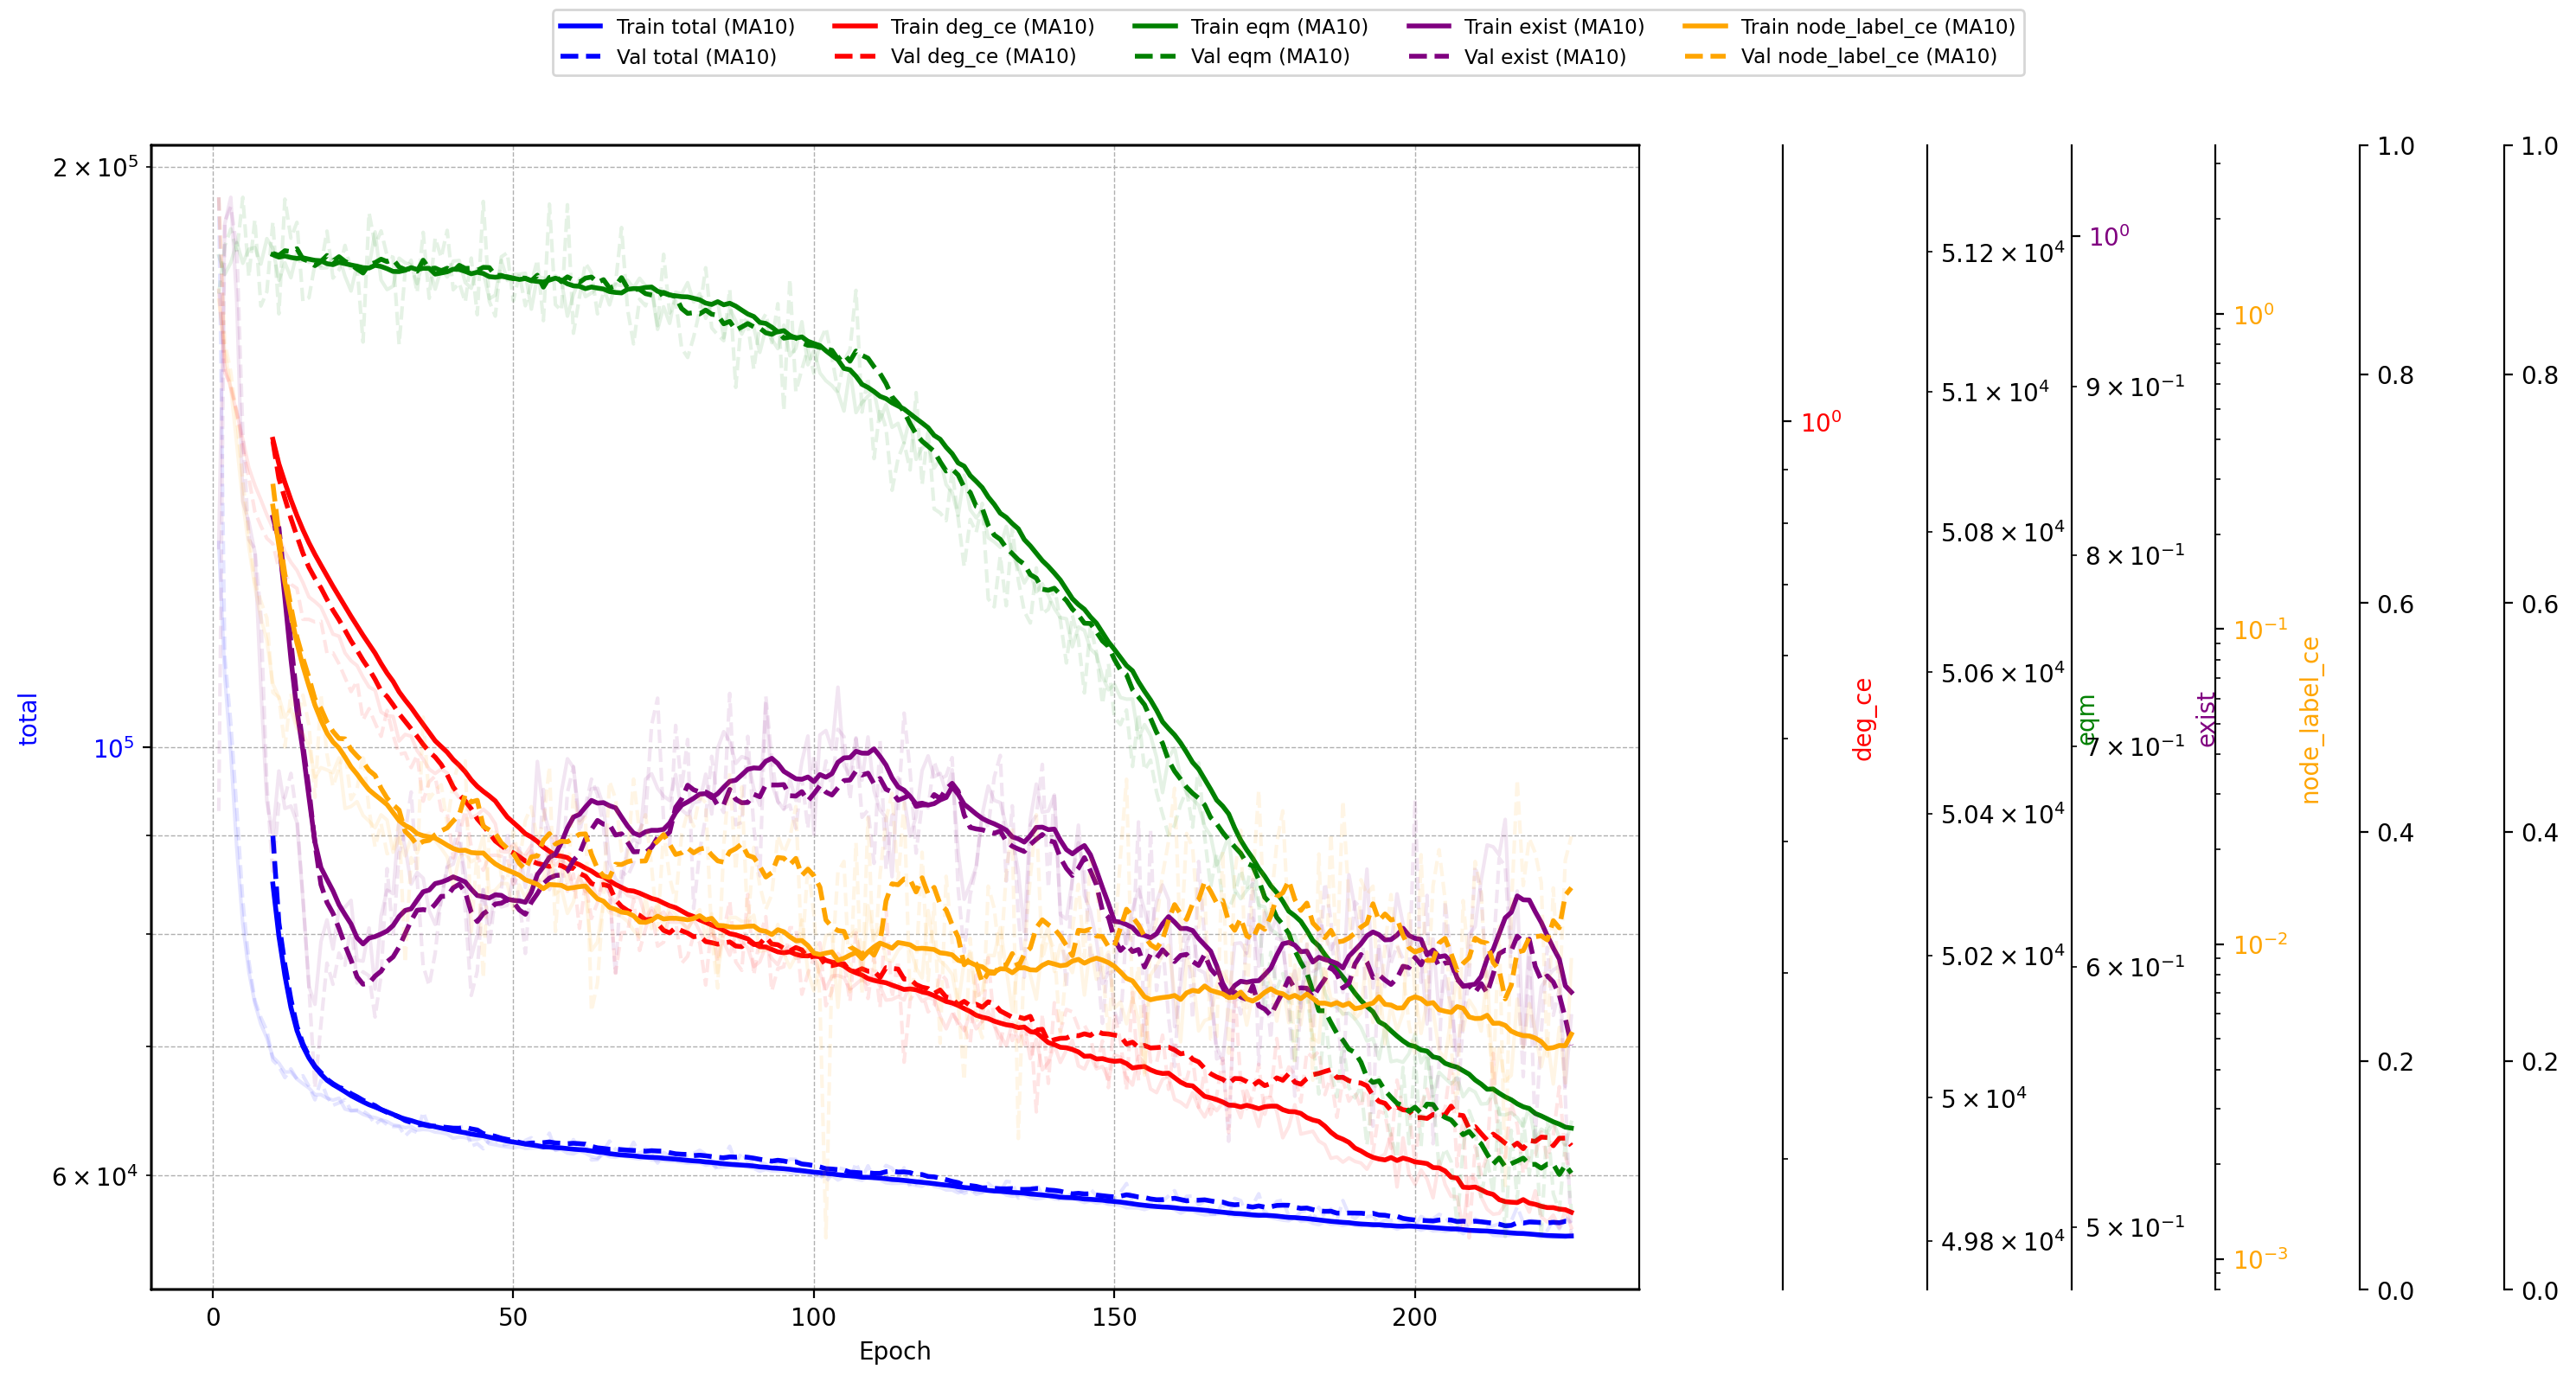

Restored best checkpoint from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_328517c07e664ea2b64fa3a53c815c33/best-205-55985.5898.ckpt (best_epoch=206, val_total=55985.5898, stopped_epoch=227).
CPU times: user 4h 11min 5s, sys: 22min 31s, total: 4h 33min 36s
Wall time: 36min 38s


In [75]:
%%time
graph_generator = fit_graph_generator(graph_generator, train_graphs)


## Conditioning vs Generated Label Histograms

In [76]:
label_histogram_summary = run_label_histogram_analysis(graph_generator, train_graphs, n_compare=5)


Label vocabulary: ['Br', 'C', 'Cl', 'F', 'N', 'O', 'P', 'S']
Conditioning histogram from first real graph: {'Br': 0.0, 'C': 0.72, 'Cl': 0.0, 'F': 0.0, 'N': 0.08, 'O': 0.16, 'P': 0.0, 'S': 0.04}


KeyboardInterrupt: 

Positive Graphs:


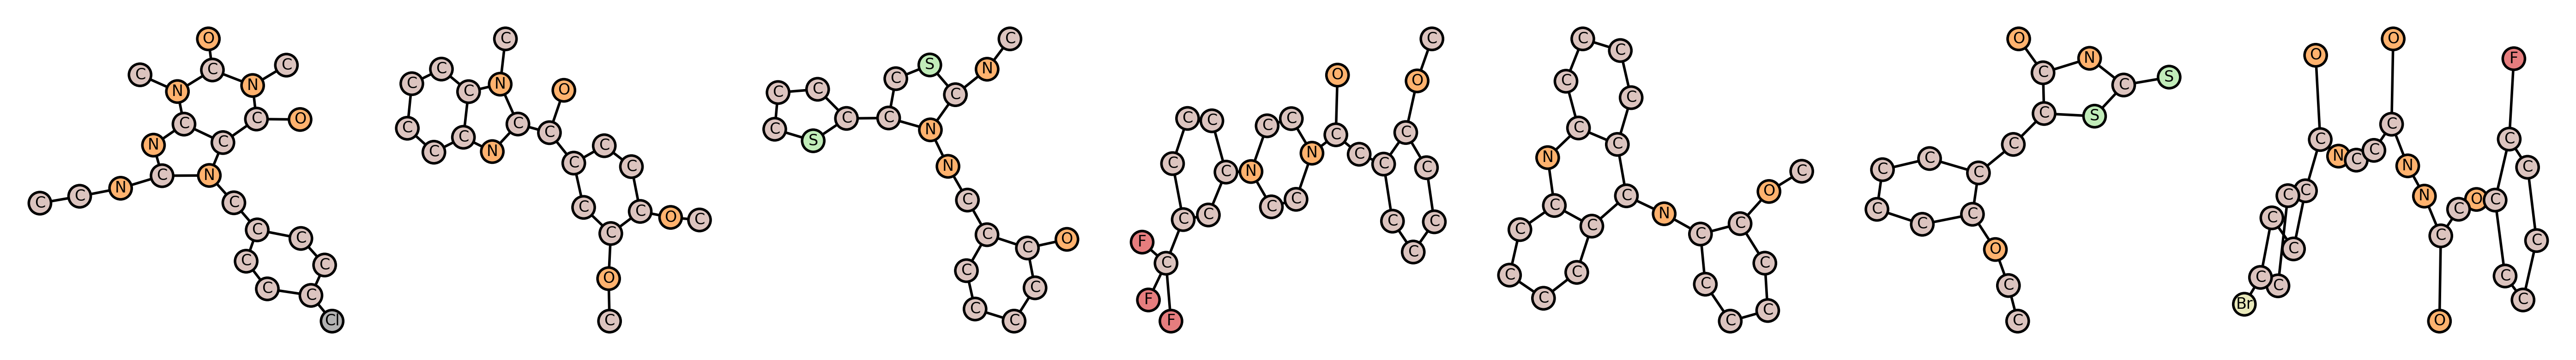

Sampled Positive Graphs Without Feasibility Filtering (7/7):


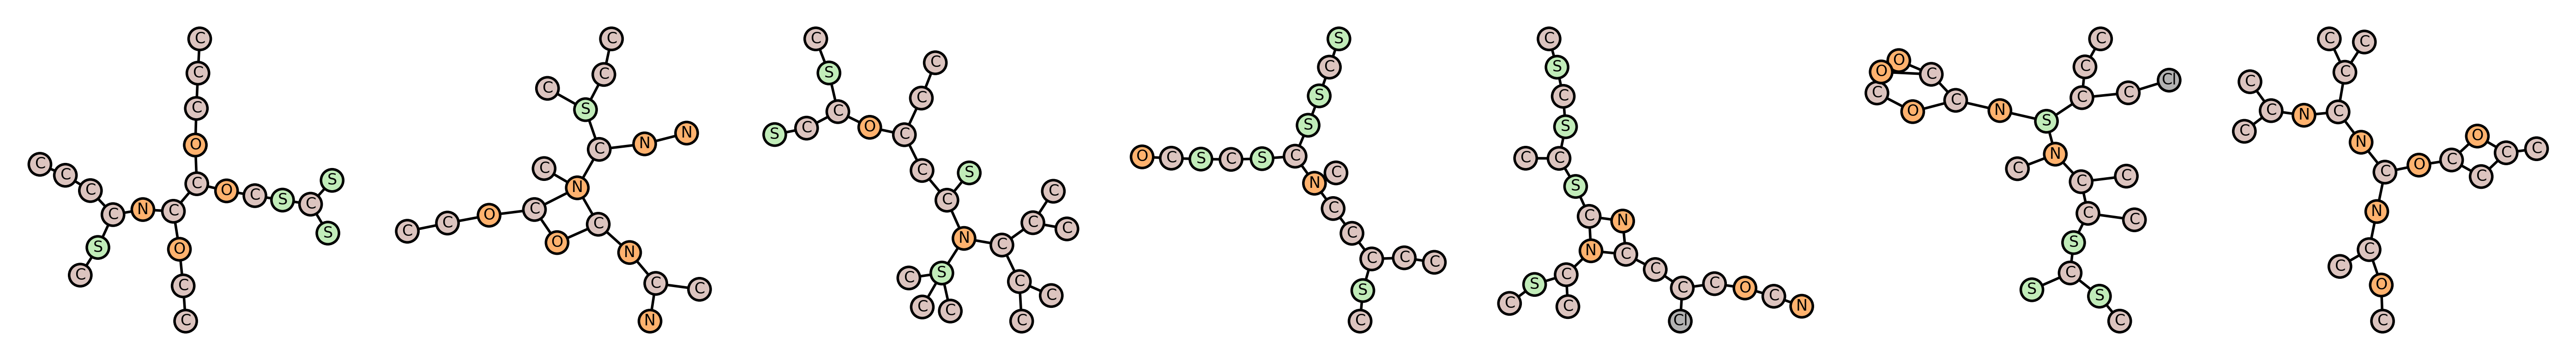

Feasibility attempt  1/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  2/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  3/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  4/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  5/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  6/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  7/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibility attempt  8/20 | generated=  56 | accepted= 0 | rejected= 7 | rate=  0.0% | accepted_total= 0 | missing_total= 7
Feasibil

In [ ]:
show_samples(n_samples=7, graphs=train_graphs, targets=train_targets, graph_generator=graph_generator)

In [ ]:
show_samples(n_samples=7, graphs=test_graphs, targets=test_targets, graph_generator=graph_generator)

## Positive-to-Positive Conditioning Interpolation

Select two positive training graphs at random, interpolate between them, and display the endpoints plus feasible generated graphs.

In [ ]:
selected_indices, selected_targets, endpoint_graph_a, endpoint_graph_b = sample_positive_endpoint_pair(
    train_graphs,
    train_targets,
)
print("Endpoint indices:", selected_indices)
print("Endpoint targets:", selected_targets)

display_mode = 'molecule' if DATASET_TYPE == 'MOLECULAR' else 'not_molecule'
print("Selected endpoint graphs:")
plot_networkx_graphs([endpoint_graph_a, endpoint_graph_b], n_cols=2, mode=display_mode)

interpolation_result = interpolate(
    graph_generator,
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=True,
)
display(interpolation_result["summary"])

missing_steps = interpolation_result["summary"].loc[
    ~interpolation_result["summary"]["decoded"],
    "step",
].tolist()
if missing_steps:
    print("Interpolation steps rejected by feasibility filtering:", missing_steps)

graphs_to_display = [endpoint_graph_a, *interpolation_result["generated_graphs"], endpoint_graph_b]
print("Endpoints and generated interpolation graphs:")
plot_networkx_graphs(graphs_to_display, n_cols=max(1, len(graphs_to_display)), mode=display_mode)


## Real vs Generated Distribution Comparison

In [ ]:
distribution_comparison = compare_real_vs_generated(
    graph_generator,
    test_graphs,
    apply_feasibility_filtering=True,
)


---